# 1. Filter Methods: Variance Threshold & Correlation Pruning

This notebook covers:
1. **Low Variance Filtering**: Removing constant (zero variance) and quasi-constant (near-zero variance) features.
2. **Variance Math**: Why variance is scale-dependent and why scaling or discrete ratio analysis must precede thresholding.
3. **Multicollinearity & Correlation Pruning**: Identifying redundant feature pairs using Pearson / Spearman correlation matrices.
4. **Automated Pruning Function**: Programmatically dropping redundant collinear features above a strict threshold (e.g., $r > 0.85$) while keeping the single most informative column.
5. **Impact on Downstream Model**: Comparing inference latency and evaluation before and after filtering.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Set random seed for reproducibility
np.random.seed(42)

# 1. Synthesize a dataset with informative, redundant, constant, and quasi-constant features
X_raw, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    random_state=42
)

df = pd.DataFrame(X_raw, columns=[f'Feature_{i}' for i in range(1, 7)])

# 2. Inject pathological features commonly encountered in real tabular datasets:
# - Completely constant column (Zero variance)
df['Constant_Col'] = 100.0

# - Quasi-constant column (99% identical values, Near-zero variance)
quasi = np.zeros(len(df))
quasi[np.random.choice(len(df), size=8, replace=False)] = 1
df['Quasi_Constant_Col'] = quasi

# - Highly collinear feature (Duplicate information with slight noise added)
df['Collinear_Feature_1'] = df['Feature_1'] * 2.5 + np.random.normal(0, 0.05, size=len(df))

# Add target
df['Target'] = y

print("=== RAW SYNTHESIZED DATASET SHAPE ===")
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")
display(df.head())

=== RAW SYNTHESIZED DATASET SHAPE ===
Total rows: 1000, Total columns: 10


,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Constant_Col,Quasi_Constant_Col,Collinear_Feature_1,Target
0,0.351385,2.182377,-0.255875,-0.388255,0.892724,-0.868436,100.0,0.0,0.848364,1
1,-1.800301,0.169075,1.640729,-1.884878,2.475151,0.236966,100.0,0.0,-4.462740,0
2,-0.907700,1.365479,-1.349986,-0.732752,1.534017,-1.771557,100.0,0.0,-2.213934,1
3,1.168221,-2.001491,-0.103807,1.528139,-2.402107,2.811396,100.0,0.0,2.959135,1
4,-0.869636,1.487769,-1.373556,-1.545475,2.116369,-1.050364,100.0,0.0,-2.210257,1


---
## Step 1: Train / Test Split

Filtering rules (thresholds and correlation matrices) must always be calculated **strictly on the training set** to prevent data leakage.

In [2]:
X = df.drop(columns=['Target']).copy()
y = df['Target'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (750, 9)
X_test shape:  (250, 9)


---
## Step 2: Variance Thresholding (Constant & Quasi-Constant Pruning)

A feature with zero variance carries zero information because it cannot separate class 0 from class 1.
Similarly, a quasi-constant feature where $99\%$ of values are identical offers negligible discriminatory power and wastes model capacity.

* **Zero Variance Threshold**: `threshold=0.0`
* **Quasi-Constant Threshold for Bernoulli/Binary features**:
  $$\text{Var}(X) = p(1 - p)$$
  For a binary column where $99\%$ of values belong to one class:
  $$\text{Var} = 0.99 \times (1 - 0.99) = 0.0099$$

In [3]:
# 1. Identify and remove zero-variance and quasi-constant columns (threshold = 0.01)
selector_var = VarianceThreshold(threshold=0.01)

# Fit strictly on X_train
selector_var.fit(X_train)

# Identify kept vs dropped columns
kept_columns = X_train.columns[selector_var.get_support()]
dropped_columns = X_train.columns[~selector_var.get_support()]

print(f"Original feature count: {X_train.shape[1]}")
print(f"Features removed by VarianceThreshold: {list(dropped_columns)}")
print(f"Features retained: {list(kept_columns)}")

# Transform both train and test splits
X_train_var = pd.DataFrame(selector_var.transform(X_train), columns=kept_columns, index = X_train.index)
X_test_var = pd.DataFrame(selector_var.transform(X_test), columns=kept_columns, index= X_test.index)

Original feature count: 9
Features removed by VarianceThreshold: ['Constant_Col', 'Quasi_Constant_Col']
Features retained: ['Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Collinear_Feature_1']


---
## Step 3: Correlation Analysis (Multicollinearity)

When two features are strongly correlated ($|r| > 0.85$), they provide redundant information. 
Retaining both:
* Inflates the variance of coefficients in linear/logistic regression.
* Dilutes feature importance scores in tree models.
* Increases inference compute unnecessarily.

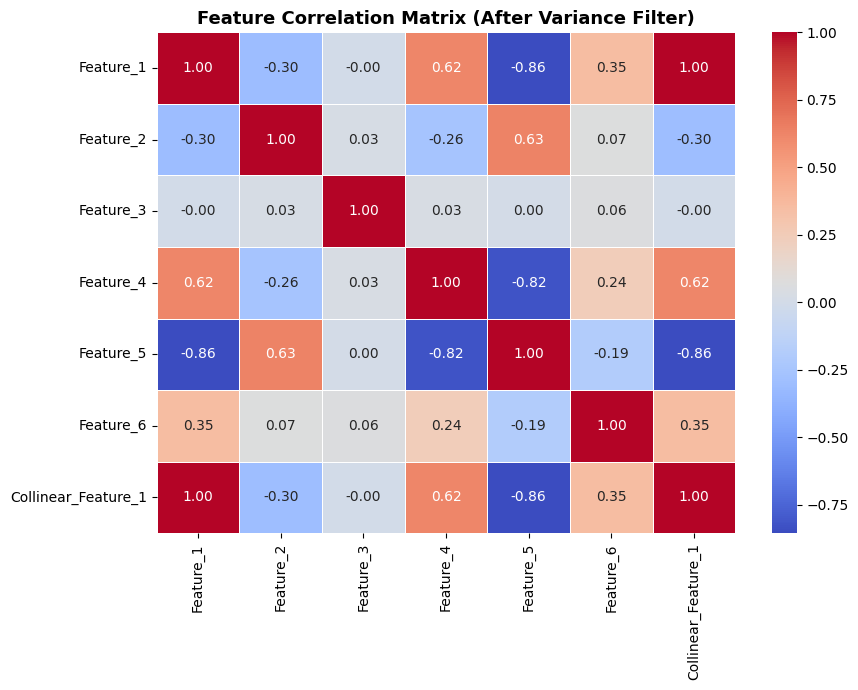

In [4]:
# Compute Pearson correlation matrix on training set
corr_matrix = X_train_var.corr()

# Visualize correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, linewidths=0.5)
plt.title("Feature Correlation Matrix (After Variance Filter)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: Automated Correlation Pruning

### What is Happening Under the Hood?
A correlation matrix is completely symmetrical across its diagonal:
* The correlation between `Feature A` and `Feature B` is identical to the correlation between `Feature B` and `Feature A`.
* Every feature has a correlation of `1.0` with itself along the diagonal.

If we simply wrote a rule saying *"drop any column with correlation > 0.85"*, both `Feature A` and `Feature B` would be flagged, causing us to accidentally delete **both** columns and lose the signal entirely.

A correlation matrix is completely symmetrical:

```text
           Feature_A   Feature_B
Feature_A    1.00        0.92
Feature_B    0.92        1.00

```

Notice that `0.92` appears twice (once above the diagonal, once below).

* If you just do `if corr > 0.85: drop both`, you would drop **both** `Feature_A` and `Feature_B` and lose the data entirely.

To prevent this:
1. We inspect only the **upper triangle** above the diagonal line (`np.triu` in raw NumPy).
2. For any pair where correlation exceeds `0.85`, we flag **only one** of the two features for removal.
3. The first feature is kept to preserve the predictive signal, while the redundant duplicate is discarded.

### Production Implementation: `feature-engine`
Rather than maintaining custom loops or triangle masks in production, we use `feature-engine.selection.DropCorrelatedFeatures`. It packages this exact upper-triangle logic into a robust Scikit-Learn compatible transformer.

In [5]:
from feature_engine.selection import DropCorrelatedFeatures

# Automatically detects pairs with |r| > 0.85 and drops the redundant column
tr = DropCorrelatedFeatures(threshold=0.85, method='pearson')

# Fit strictly on train, transform both
X_train_filtered = tr.fit_transform(X_train_var)
X_test_filtered  = tr.transform(X_test_var)

print("Dropped columns:", tr.features_to_drop_)

Dropped columns: ['Feature_1', 'Feature_5']


---
## Step 5: Downstream Model Comparison

We benchmark a `RandomForestClassifier` trained on:
1. **Raw Full Feature Set** (9 features including noise, constants, and duplicates).
2. **Filtered Feature Set** (Only clean, non-redundant informative features).

In [6]:
# 1. Model on Raw Data
rf_raw = RandomForestClassifier(random_state=42)
rf_raw.fit(X_train, y_train)
y_pred_raw = rf_raw.predict(X_test)

# 2. Model on Filtered Data
rf_filtered = RandomForestClassifier(random_state=42)
rf_filtered.fit(X_train_filtered, y_train_filtered := y_train)
y_pred_filtered = rf_filtered.predict(X_test_filtered)

print("=== 1. PERFORMANCE ON RAW FEATURES (9 Features) ===")
print(classification_report(y_test, y_pred_raw, target_names=['Class 0', 'Class 1']))

print("=== 2. PERFORMANCE ON FILTERED FEATURES (Reduced Subset) ===")
print(classification_report(y_test, y_pred_filtered, target_names=['Class 0', 'Class 1']))

=== 1. PERFORMANCE ON RAW FEATURES (9 Features) ===
              precision    recall  f1-score   support

     Class 0       0.94      0.90      0.92       125
     Class 1       0.91      0.94      0.93       125

    accuracy                           0.92       250
   macro avg       0.92      0.92      0.92       250
weighted avg       0.92      0.92      0.92       250

=== 2. PERFORMANCE ON FILTERED FEATURES (Reduced Subset) ===
              precision    recall  f1-score   support

     Class 0       0.92      0.90      0.91       125
     Class 1       0.90      0.92      0.91       125

    accuracy                           0.91       250
   macro avg       0.91      0.91      0.91       250
weighted avg       0.91      0.91      0.91       250



---
## Key Takeaways

1. **Variance Threshold is Unsupervised**: It evaluates feature variation independently of target $y$. It is fast and safe to run as a preliminary hygiene step.
2. **Scale Sensitivity**: Never apply continuous variance thresholding without standardizing features first, as raw numeric scale directly scales variance.
3. **Correlation Pruning Preserves Signal**: Pruning $|r| > 0.85$ removes redundant computation without degrading predictive performance.

Here is the direct, step-by-step breakdown addressing every single doubt.

---

### 1. What is this notebook really about, and why can't we just look at the data manually?

* **Why not look manually?**
In a toy dataset with 5 columns, you *can* look at it manually. But in real-world tabular data (e.g., credit card fraud, user clickstream, or medical records), you frequently deal with **150 to 500+ features**. You cannot manually inspect 500 columns or plot $500 \times 500 = 250,000$ scatter plots to see what is useful.
* **Why do we drop features at all?**
If you feed a model 100 random noise columns alongside 5 informative columns, algorithms (especially tree ensembles and neural networks) will start finding false patterns in the noise. This causes **overfitting**, blows up training time, and makes inference slow in production.
* **Why are there multiple techniques?**
Different features break in different ways:
* Some features have **zero variation** (everyone has the exact same value) $\rightarrow$ Handled by **Variance Threshold**.
* Some features are **duplicates of each other** (telling the exact same story twice) $\rightarrow$ Handled by **Correlation Filters**.
* Some features have **no relationship with the target $y$** $\rightarrow$ Handled by **Statistical / Mutual Information Filters** (Notebook 2).



---

### 2. What is `VarianceThreshold`, and is it just calculating variance?

Yes. It **literally calculates the mathematical variance ($\sigma^2$)** of each column:

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2$$

* If every single person in a dataset has `Country = India`, the variance of that column is **$0.0$**. A column with zero variance gives a machine learning model zero ability to distinguish between Class 0 and Class 1.
* If a column has variance lower than your cutoff threshold, `VarianceThreshold` drops it. That's all it does.

---

### 3 & 4. Why did those columns exist, and why were they named like that?

You are completely right: the names `Constant_Col`, `Quasi_Constant_Col`, and `Collinear_Feature_1` were named explicitly to make it obvious what was being injected for demonstration purposes. In reality, these columns look like normal features, for example:

* **Real-world Constant Column:** A column called `Platform` where every single user signed up on `Android` because the iOS app hasn't launched yet.
* **Real-world Quasi-Constant Column:** A column called `Failed_Payment_Count_Past_24h` where 99.9% of rows are `0`, and only 2 rows are `1`.
* **Real-world Collinear Column:** A column called `Income_Monthly` and another called `Income_Annual` (where one is just the other multiplied by 12).

---

### 5. How do you pick the threshold value in `VarianceThreshold(threshold=...)`?

There are two primary ways:

1. **The Default Safe Setting (`threshold=0.0`):**
This removes **only pure constants** (columns where every single value is identical). This is zero-risk and requires no guessing.
2. **For Binary (0 or 1) features:**
For a binary feature, variance is calculated using the Bernoulli formula: $\text{Var} = p(1-p)$, where $p$ is the fraction of the dominant class.
* If you want to drop a binary column where **$99\%$ of rows are identical**, set:

$$\text{Threshold} = 0.99 \times (1 - 0.99) = \mathbf{0.0099} \approx 0.01$$


* If you want to drop a binary column where **$95\%$ of rows are identical**, set:

$$\text{Threshold} = 0.95 \times (1 - 0.95) = \mathbf{0.0475}$$





*(Note: Never use arbitrary variance numbers on continuous features without scaling them first, because a salary in Rupees will have massive variance simply due to its scale).*

---

### 6. What is `.get_support()`, what does `~` mean, and what does that line do?

* **`selector_var.get_support()`**:
Returns a simple NumPy array of **booleans (`True` or `False`)** corresponding to each column.
* `True` = Column variance is **GREATER** than the threshold (Keep it).
* `False` = Column variance is **LOWER** than the threshold (Drop it).


* **What `X_train.columns[selector_var.get_support()]` does:**
It filters the column names using boolean indexing:
```python
# If columns = ['Age', 'Salary', 'Constant_Col']
# get_support() = [True, True, False]
# Result = ['Age', 'Salary']

```


* **What `~` means:**
In Python and NumPy, the tilde symbol **`~` is the NOT operator (inversion)**.
* It flips every `True` to `False`, and every `False` to `True`.
* Therefore, `~selector_var.get_support()` selects only the columns that were **dropped**.



---

### 7. What is happening in the last two lines of Cell 6?

```python
X_train_var = pd.DataFrame(selector_var.transform(X_train), columns=kept_columns, index=X_train.index)

```

1. **`selector_var.transform(X_train)`**:
Takes the original matrix and removes the low-variance column. **However, Scikit-Learn returns a raw NumPy array**, losing your column names and row index.
2. **`pd.DataFrame(...)`**:
Wraps the raw NumPy array back into a pandas DataFrame.
* `columns=kept_columns`: Restores the proper column names.
* `index=X_train.index`: Keeps the original row numbers intact.



---

### 8. Cell 8 Note

Your understanding is spot on: it simply calculates the correlation matrix and draws a heatmap to visually show features that mirror each other.

---
### 9. Moving Forward

For all future markdown and code explanations:

* Technical jargon will be replaced with direct, plain-English explanations.
* Code will prioritize clarity and readability over dense one-liners.
* Every dataset will reflect realistic business features (e.g., `account_age`, `monthly_spend`, `login_count`).